# Session 1: visualization of representative 30-s windows

The first available 30-s child window is selected deterministically within each state (Awake and Drowsy). The notebook shows the Processed PPG waveform and a three-coordinate projection of the full time-delay embedding with the frozen parameters $m=8$ and $\tau=0.16$ s.

In [1]:
# Cell 1 — Config, load with get_data, deterministic selection, and QC
from pathlib import Path
import sys
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from IPython.display import display


def find_phase1_dir(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'dataloader' / 'loader.py').is_file() and (candidate / 'segmentated_data').is_dir():
            return candidate
        phase1 = candidate / 'phase1'
        if (phase1 / 'src' / 'dataloader' / 'loader.py').is_file() and (phase1 / 'segmentated_data').is_dir():
            return phase1
    raise FileNotFoundError('Could not locate the phase1 directory.')


PHASE1_DIR = find_phase1_dir(Path.cwd())
SRC_DIR = PHASE1_DIR / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dataloader.loader import get_data
from embedding.psr import reconstruct_phase_space

DATA_DIR = PHASE1_DIR / 'segmentated_data' / '30s_dhdata'
INDEX_PATH = DATA_DIR / 'segments_index.csv'
OUTPUT_DIR = PHASE1_DIR / 'outputs' / '30s_window_test'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SESSION = 'sample_1'
WINDOW_SIZE_S = 30
M_FINAL = 8
TAU_FINAL_S = 0.16
STATE_SPECS = (('Awake', 0, '#2166ac'), ('Drowsy', 1, '#b2182b'))

required_font = 'Times New Roman'
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
ACTIVE_FONT = required_font if required_font in available_fonts else ('Liberation Serif' if 'Liberation Serif' in available_fonts else 'DejaVu Serif')
if ACTIVE_FONT != required_font:
    warnings.warn(f'{required_font} is unavailable; using {ACTIVE_FONT}.', RuntimeWarning, stacklevel=1)
mpl.rcParams.update({
    'font.family': ACTIVE_FONT, 'font.size': 10, 'axes.labelsize': 11,
    'axes.linewidth': 1.0, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'savefig.facecolor': 'white', 'savefig.transparent': False,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})


def require(condition: bool, message: str) -> None:
    if not condition:
        raise ValueError(message)


def save_figure(fig: mpl.figure.Figure, stem: str) -> None:
    for suffix, kwargs in (('png', {'dpi': 600}), ('pdf', {}), ('svg', {})):
        fig.savefig(OUTPUT_DIR / f'{stem}.{suffix}', bbox_inches='tight', **kwargs)


awake, drowsy = get_data(
    SESSION, data_dir=DATA_DIR, window_sizes=WINDOW_SIZE_S, stationarity='processed'
)
index = pd.read_csv(INDEX_PATH)
session_index = index.loc[
    index['npz_file'].eq(f'{SESSION}.npz') & index['window_size_s'].eq(WINDOW_SIZE_S)
].copy()
require(not session_index.empty, f'No indexed 30-s windows found for {SESSION}.')

records = []
for state, label, color in STATE_SPECS:
    batch = awake[WINDOW_SIZE_S] if label == 0 else drowsy[WINDOW_SIZE_S]
    require(len(batch['window_id']) > 0, f'No {state} windows found for {SESSION}.')
    window_id = int(np.min(batch['window_id']))
    position = int(np.flatnonzero(batch['window_id'] == window_id)[0])
    signal = np.asarray(batch['processed'][position], dtype=float)
    absolute_time = np.asarray(batch['time'][position], dtype=float)
    fs = float(batch['fs'])
    row = session_index.loc[(session_index['label'].eq(label)) & (session_index['window_id'].eq(window_id))]
    require(len(row) == 1, f'Expected one index row for {state} window {window_id}; found {len(row)}.')
    row = row.iloc[0]
    require(signal.ndim == absolute_time.ndim == 1 and len(signal) == len(absolute_time), f'{state}: signal/time alignment failed.')
    require(len(signal) == int(round(WINDOW_SIZE_S * fs)), f'{state}: expected {round(WINDOW_SIZE_S * fs)} samples, found {len(signal)}.')
    require(np.isfinite(signal).all() and np.isfinite(absolute_time).all(), f'{state}: non-finite values detected.')
    require(np.all(np.diff(absolute_time) > 0), f'{state}: timestamps are not strictly increasing.')
    delay_samples = int(round(TAU_FINAL_S * fs))
    realized_tau_s = delay_samples / fs
    require(abs(realized_tau_s - TAU_FINAL_S) <= 0.5 / fs + 1e-12, f'{state}: frozen delay cannot be represented within half a sample.')
    records.append({
        'state': state, 'label': label, 'color': color, 'window_id': window_id,
        'window_30_id': row['window_30_id'], 'parent_window_60_id': row['parent_window_60_id'],
        'subwindow': row['subwindow'], 'signal': signal,
        'time_s': absolute_time - absolute_time[0], 'fs': fs,
        'delay_samples': delay_samples, 'realized_tau_s': realized_tau_s,
    })

selection_table = pd.DataFrame([{
    'Session': SESSION, 'State': r['state'], 'Window ID': r['window_id'],
    '30-s window ID': r['window_30_id'], 'Parent 60-s window': r['parent_window_60_id'],
    'Subwindow': r['subwindow'], 'Samples': len(r['signal']), 'fs (Hz)': r['fs'],
    'tau (samples)': r['delay_samples'], 'realized tau (s)': r['realized_tau_s'],
} for r in records])
display(selection_table)
print(f'Selection QC: PASS | deterministic first child per state | font={ACTIVE_FONT}')

/tmp/ipykernel_9297/3433973846.py:47: RuntimeWarning: Times New Roman is unavailable; using Liberation Serif.
  warnings.warn(f'{required_font} is unavailable; using {ACTIVE_FONT}.', RuntimeWarning, stacklevel=1)


,Session,State,Window ID,30-s window ID,Parent 60-s window,Subwindow,Samples,fs (Hz),tau (samples),realized tau (s)
0,sample_1,Awake,1,sample_1_awake_w0001_60s_h1,sample_1_awake_w0001_60s,h1,1500,50.0,8,0.16
1,sample_1,Drowsy,49,sample_1_drowsy_w0018_60s_h1,sample_1_drowsy_w0018_60s,h1,1500,50.0,8,0.16


Selection QC: PASS | deterministic first child per state | font=Liberation Serif


## Experiment 1 — Processed PPG waveform

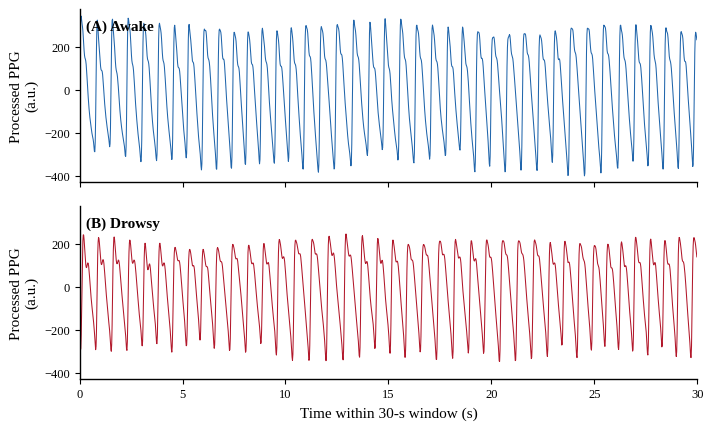

Waveform figure saved as PNG, PDF, and SVG: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/30s_window_test


In [2]:
# Cell 2 — Waveform visualization
all_amplitudes = np.concatenate([record['signal'] for record in records])
amplitude_min, amplitude_max = float(all_amplitudes.min()), float(all_amplitudes.max())
amplitude_padding = 0.04 * max(amplitude_max - amplitude_min, np.finfo(float).eps)

fig, axes = plt.subplots(2, 1, figsize=(7.10, 4.35), sharex=True, sharey=True)
for panel_index, (ax, record) in enumerate(zip(axes, records)):
    ax.plot(record['time_s'], record['signal'], color=record['color'], linewidth=0.75)
    ax.set_xlim(0, WINDOW_SIZE_S)
    ax.set_ylim(amplitude_min - amplitude_padding, amplitude_max + amplitude_padding)
    ax.set_ylabel('Processed PPG\n(a.u.)')
    ax.spines[['top', 'right']].set_visible(False)
    ax.text(0.01, 0.94, f"({'AB'[panel_index]}) {record['state']}", transform=ax.transAxes, va='top', ha='left', fontsize=11, fontweight='bold')
axes[-1].set_xlabel('Time within 30-s window (s)')
fig.subplots_adjust(left=0.12, right=0.99, bottom=0.13, top=0.98, hspace=0.14)
save_figure(fig, 'session_1_30s_waveforms')
plt.show()
print('Waveform figure saved as PNG, PDF, and SVG:', OUTPUT_DIR)

## Experiment 2 — Phase-space reconstruction

The reconstruction is computed in eight dimensions. For visualization only, each panel displays the first three delayed coordinates: $[x(t), x(t+\tau), x(t+2\tau)]$.

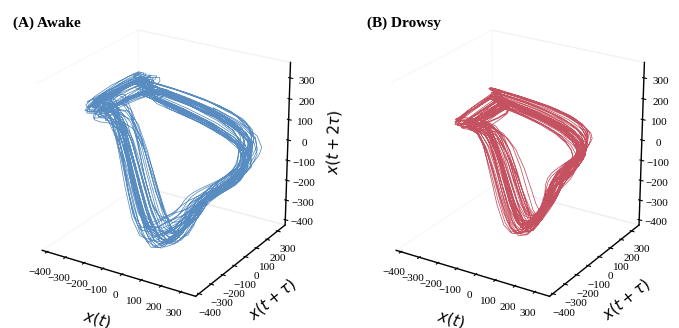

Awake: full embedding=(1444, 8); displayed projection=(1444, 3); tau=8 samples (0.16 s)
Drowsy: full embedding=(1444, 8); displayed projection=(1444, 3); tau=8 samples (0.16 s)
Phase-space QC: PASS. Both panels use unnormalized Processed PPG amplitude, identical axis limits, camera angle, and line settings.
Phase-space figure saved as PNG, PDF, and SVG: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/30s_window_test


In [3]:
# Cell 3 — Full m=8 embedding and common-scale 3D projection
for record in records:
    record['embedding'] = reconstruct_phase_space(record['signal'], M_FINAL, record['delay_samples'])
    record['projection'] = record['embedding'][:, :3]

all_coordinates = np.concatenate([record['projection'].ravel() for record in records])
coordinate_min, coordinate_max = float(all_coordinates.min()), float(all_coordinates.max())
coordinate_padding = 0.04 * max(coordinate_max - coordinate_min, np.finfo(float).eps)
shared_limits = (coordinate_min - coordinate_padding, coordinate_max + coordinate_padding)

fig = plt.figure(figsize=(7.10, 3.65), constrained_layout=False)
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.14, top=0.97, wspace=0.08)
for panel_index, record in enumerate(records, start=1):
    ax = fig.add_subplot(1, 2, panel_index, projection='3d')
    projection = record['projection']
    ax.plot(projection[:, 0], projection[:, 1], projection[:, 2], color=record['color'], linewidth=0.55, alpha=0.75)
    ax.set_xlim(shared_limits); ax.set_ylim(shared_limits); ax.set_zlim(shared_limits)
    ax.set_box_aspect((1, 1, 1)); ax.view_init(elev=24, azim=-58)
    ax.set_xlabel(r'$x(t)$', labelpad=1)
    ax.set_ylabel(r'$x(t+\tau)$', labelpad=1)
    ax.set_zlabel(r'$x(t+2\tau)$', labelpad=1)
    ax.tick_params(labelsize=8, pad=0)
    ax.grid(False)
    ax.xaxis.pane.fill = False; ax.yaxis.pane.fill = False; ax.zaxis.pane.fill = False
    ax.text2D(0.01, 0.98, f"({'AB'[panel_index-1]}) {record['state']}", transform=ax.transAxes, va='top', fontsize=11, fontweight='bold')
save_figure(fig, 'session_1_30s_phase_space_m8_tau016s')
plt.show()

for record in records:
    expected_vectors = len(record['signal']) - (M_FINAL - 1) * record['delay_samples']
    require(record['embedding'].shape == (expected_vectors, M_FINAL), f"{record['state']}: unexpected embedding shape.")
    print(f"{record['state']}: full embedding={record['embedding'].shape}; displayed projection={record['projection'].shape}; tau={record['delay_samples']} samples ({record['realized_tau_s']:.2f} s)")
print('Phase-space QC: PASS. Both panels use unnormalized Processed PPG amplitude, identical axis limits, camera angle, and line settings.')
print('Phase-space figure saved as PNG, PDF, and SVG:', OUTPUT_DIR)